# Visualization for deliveries per month
Thought showing visualizations for the number of deliveries per month might be interesting.
Could also do something to show the person receiving the most deliveries for each month?

Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec


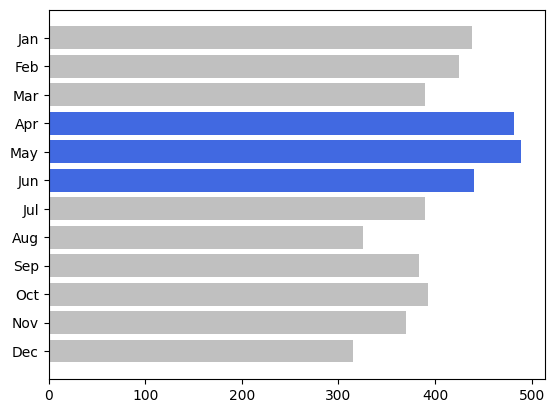

In [ ]:
import pandas as pd
from MonthEnum import Date
import matplotlib.pyplot as plt


df = pd.read_csv("../Data/PantrytoPorchData2025.csv")
df = df[["Date"]]

temp_dict = {}

for row in df.itertuples():
    date_num = int(row.Date.split("/")[0])
    cur_date = Date(date_num).name
    
    if cur_date not in temp_dict:
        temp_dict[cur_date] = 1
    
    else:
        temp_dict[cur_date] += 1

month_deliveries = pd.DataFrame.from_dict(temp_dict, orient='index', columns=['Total Deliveries'])
month_deliveries.index.name = 'Month'
month_deliveries = month_deliveries.reset_index()

fig, ax = plt.subplots()
target_months = ["Apr", "May", "Jun"]
for row in month_deliveries.itertuples():
    cur_month = row[1]
    ax.barh(cur_month, row[2], color = "royalblue" if cur_month in target_months else "silver")
ax.invert_yaxis()

plt.show()